In [29]:
# Generate simulated temperature readings from two sensors.
# Sensor A: mean 25 C, std 3 C, 200 readings.
# Sensor B: mean 27 C, std 4.5 C, 200 readings.
# Also generate 200 timestamps uniformly from 0 to 10 seconds.
# Use np.random.default_rng with a seed = last 4 digits of your Drexel ID.

In [30]:
import numpy as np

# Replace 1234 with the last 4 digits of your Drexel ID for the required seed
seed = 3693
rng = np.random.default_rng(seed)

n = 200
# timestamps uniformly in [0, 10)
t = rng.uniform(0.0, 10.0, size=n)

# independent sensor readings
sensor_a = rng.normal(loc=25.0, scale=3.0, size=n)
sensor_b = rng.normal(loc=27.0, scale=4.5, size=n)

# sort by time so data is ready for time-series plotting
order = np.argsort(t)
t = t[order]
sensor_a = sensor_a[order]
sensor_b = sensor_b[order]

# variables now available: t, sensor_a, sensor_b

In [31]:
print(sensor_a.shape)

(200,)


In [32]:
# Scatter plot: sensor reading (y-axis) vs timestamp in seconds (x-axis).
# Color Sensor A points blue and Sensor B points orange.
# Add axis labels with units, a title, and a legend.

In [33]:
# Prepare variables to match intent: timestamps (200,), sensor_a, sensor_b
timestamps = t.copy()  # already sorted timestamps from 0 to 10
# Ensure correct dtype and shape
sensor_a = np.asarray(sensor_a, dtype=np.float64)
sensor_b = np.asarray(sensor_b, dtype=np.float64)
timestamps = np.asarray(timestamps, dtype=np.float64)
assert sensor_a.shape == (200,), f"sensor_a shape {sensor_a.shape} != (200,)"
assert sensor_b.shape == (200,), f"sensor_b shape {sensor_b.shape} != (200,)"
assert timestamps.shape == (200,), f"timestamps shape {timestamps.shape} != (200,)"
print('sensor_a, sensor_b, timestamps shapes:', sensor_a.shape, sensor_b.shape, timestamps.shape)


sensor_a, sensor_b, timestamps shapes: (200,) (200,) (200,)


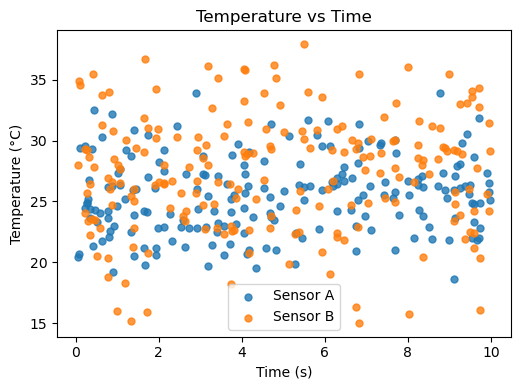

In [34]:
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(10,4))
# Time-series scatter
ax1 = plt.subplot(1,2,1)
ax1.scatter(timestamps, sensor_a, s=25, alpha=0.8, label='Sensor A', c='C0')
ax1.scatter(timestamps, sensor_b, s=25, alpha=0.8, label='Sensor B', c='C1')
ax1.set_xlabel('Time (s)')
ax1.set_ylabel('Temperature (°C)')
ax1.set_title('Temperature vs Time')
ax1.legend()

plt.tight_layout()
plt.show()


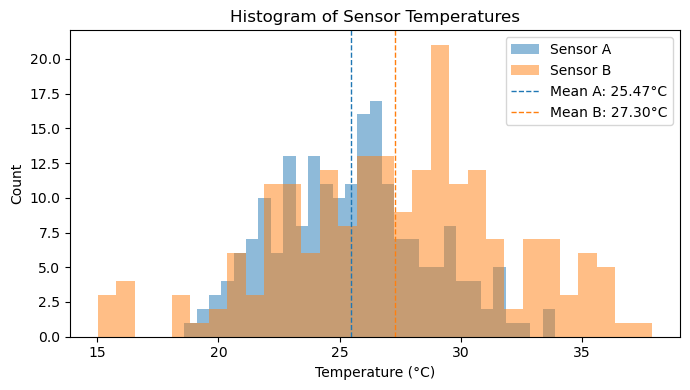

In [37]:
import matplotlib.pyplot as plt
import numpy as np

# Overlaid histogram of Sensor A and Sensor B temperature distributions.
# Use 30 bins, alpha=0.5 for transparency so both distributions are visible.
# Add vertical dashed lines at each sensor's mean.
# Include a legend labeling each sensor.
plt.figure(figsize=(7,4))
bins = 30
plt.hist(sensor_a, bins=bins, alpha=0.5, label='Sensor A', color='C0')
plt.hist(sensor_b, bins=bins, alpha=0.5, label='Sensor B', color='C1')
mean_a = float(np.mean(sensor_a))
mean_b = float(np.mean(sensor_b))
plt.axvline(mean_a, color='C0', linestyle='--', linewidth=1, label=f'Mean A: {mean_a:.2f}°C')
plt.axvline(mean_b, color='C1', linestyle='--', linewidth=1, label=f'Mean B: {mean_b:.2f}°C')
plt.xlabel('Temperature (°C)')
plt.ylabel('Count')
plt.title('Histogram of Sensor Temperatures')
plt.legend()
plt.tight_layout()
plt.show()


/var/folders/39/vscq3tss6_zg3krp0p00njc00000gn/T/ipykernel_62605/4091226202.py:12: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = plt.boxplot(data, labels=['Sensor A', 'Sensor B'],


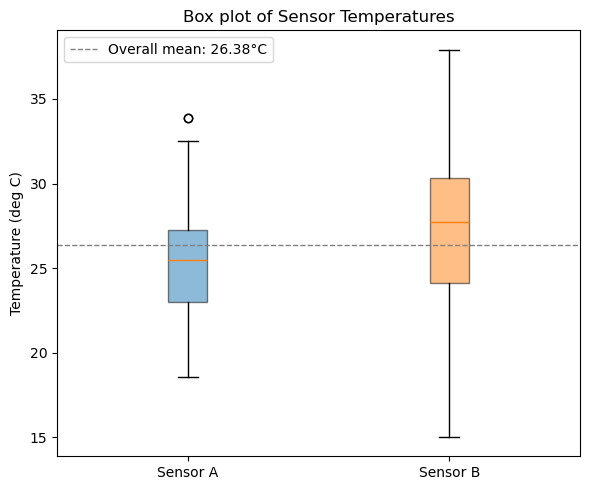

In [42]:
import matplotlib.pyplot as plt
import numpy as np
 
# Side-by-side box plot comparing Sensor A and Sensor B distributions.
# Label x-axis with sensor names, y-axis with "Temperature (deg C)".
# Add a horizontal dashed line at the overall mean of both sensors combined.
 
plt.figure(figsize=(6,5))
data = [sensor_a, sensor_b]
 
# Boxplot with colored boxes
bp = plt.boxplot(data, labels=['Sensor A', 'Sensor B'], 
patch_artist=True)
colors = ['C0', 'C1']
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.5)
 
overall_mean = float(np.mean(np.concatenate(data)))
plt.axhline(overall_mean, color='gray', linestyle='--', linewidth=1,
             label=f'Overall mean: {overall_mean:.2f}°C')
 
plt.ylabel('Temperature (deg C)')
plt.title('Box plot of Sensor Temperatures')
plt.legend()
plt.tight_layout()
plt.show()